# Coin-selection project
### Python

## Load libraries and simulation results

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [13]:
# Assuming files are stored in "saved-fees-updated" directory
data_dir = '../coin-selection-c-master/simulation/results'
files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

# Predefined colors for each strategy
strategy_colors = {
#    'MAX_BILLS': 'blue',
#    'CLOSEST_TO_EXPIRE_MIN_BILLS': 'orange',
#    'CLOSEST_TO_EXPIRE_MAX_BILLS': 'cyan',
#    'MAX_BILLS_TIME_TO_EXPIRE_WEIGHTED': 'blue',
    'RANDOM': 'magenta',
#    'MIN_BILLS': 'blue',
#    'EVEN_FROM_MIN_TO_MAX': 'red',
#    'EVEN_FROM_MAX_TO_MIN': 'pink',
    'WALLET_CORE': 'cyan',
    'GREEDY_MIN_TO_MAX_FIX': 'red',
    'CALL_EXTERNAL': 'black'
}

# Initialize an empty list to hold all data
all_data = []

# Process each file
for file_name in files:
    print(file_name)
    file_path = os.path.join(data_dir, file_name)
    with open(file_path, 'r') as file:
        # Read user type and strategy from the first line
        user_type, strategy = file.readline().strip().split(', ')
        
        # Parse the rest of the data
        for line in file:
            id, time, amount, operation, fee, coin_count, *_ = line.strip().split(', ')  # Updated here to include 'amount'
            all_data.append({
                "UserType": user_type,
                "Strategy": strategy,
                "Id": id,
                "Time": int(time),
                "Amount": int(amount),  
                "Operation": operation,  
                "Fee": int(fee),
                "FileName": file_name,
                "CoinCount": int(coin_count)
            })

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(all_data)


# Filter out DEPOSIT_REFRESH_OP right away
#df = df[(df['Operation'] != 'DEPOSIT_REFRESH_OP') & (df['Amount'] > 0)] # removed "& (df['Amount'] < 500000)" here

df['Days'] = df['Time']/3600/24
df = df.loc[(df["UserType"] == "ARTIST")]

n_user_types = df["UserType"].nunique()
n_strats = df["Strategy"].nunique()

cols = min(n_user_types, 2)
rows = np.ceil(n_user_types / cols).astype(int)

print(df["UserType"].unique())
print(f"{n_user_types} UserTypes")
print(f"{n_strats} Strategies")
print(f"Plotting Grid: {rows}x{cols}")
df.describe()


user_3_strategy_RANDOM.csv
user_4_strategy_GREEDY_MAX_TO_MIN_FIX.csv
user_1_strategy_GREEDY_MAX_TO_MIN_FIX.csv
user_8_strategy_CALL_EXTERNAL.csv
user_8_strategy_RANDOM.csv
user_1_strategy_GREEDY_MIN_TO_MAX_FIX.csv
user_0_strategy_RANDOM.csv
user_5_strategy_GREEDY_MIN_TO_MAX_FIX.csv
user_2_strategy_GREEDY_MIN_TO_MAX_FIX.csv
user_5_strategy_RANDOM.csv
user_6_strategy_RANDOM.csv
user_3_strategy_GREEDY_MAX_TO_MIN_FIX.csv
user_2_strategy_CALL_EXTERNAL.csv
user_4_strategy_GREEDY_MIN_TO_MAX_FIX.csv
user_7_strategy_CALL_EXTERNAL.csv
user_0_strategy_CALL_EXTERNAL.csv
user_5_strategy_GREEDY_MAX_TO_MIN_FIX.csv
user_1_strategy_CALL_EXTERNAL.csv
user_7_strategy_RANDOM.csv
user_2_strategy_GREEDY_MAX_TO_MIN_FIX.csv
user_3_strategy_CALL_EXTERNAL.csv
user_0_strategy_GREEDY_MIN_TO_MAX_FIX.csv
user_3_strategy_GREEDY_MIN_TO_MAX_FIX.csv
user_8_strategy_GREEDY_MAX_TO_MIN_FIX.csv
user_7_strategy_GREEDY_MIN_TO_MAX_FIX.csv
user_6_strategy_GREEDY_MIN_TO_MAX_FIX.csv
user_6_strategy_GREEDY_MAX_TO_MIN_FIX.csv
user

,Time,Amount,Fee,CoinCount,Days
count,1.054200e+04,1.054200e+04,10542.000000,10542.000000,10542.000000
mean,4.794428e+07,1.825000e+05,3.500664,5585.281730,554.910643
std,2.748252e+07,4.498137e+05,4.744506,4752.314714,318.084755
min,8.640000e+04,0.000000e+00,0.000000,0.000000,1.000000
25%,2.393280e+07,0.000000e+00,1.000000,1140.000000,277.000000
50%,4.812480e+07,1.497200e+04,1.000000,4608.000000,557.000000
75%,7.205760e+07,2.329675e+04,4.000000,9108.000000,834.000000
max,9.322560e+07,1.997007e+06,40.000000,15759.000000,1079.000000


In [14]:
df["SignAmount"] = 0
df["SignAmount"] = df['Amount'].where(df["Operation"] == "WITHDRAW_OP", -df["Amount"]) - df["Fee"]

file_groups = df.groupby('FileName')
df["Balance"] = file_groups['SignAmount'].cumsum()





## Generate cumulative fee for each user over time

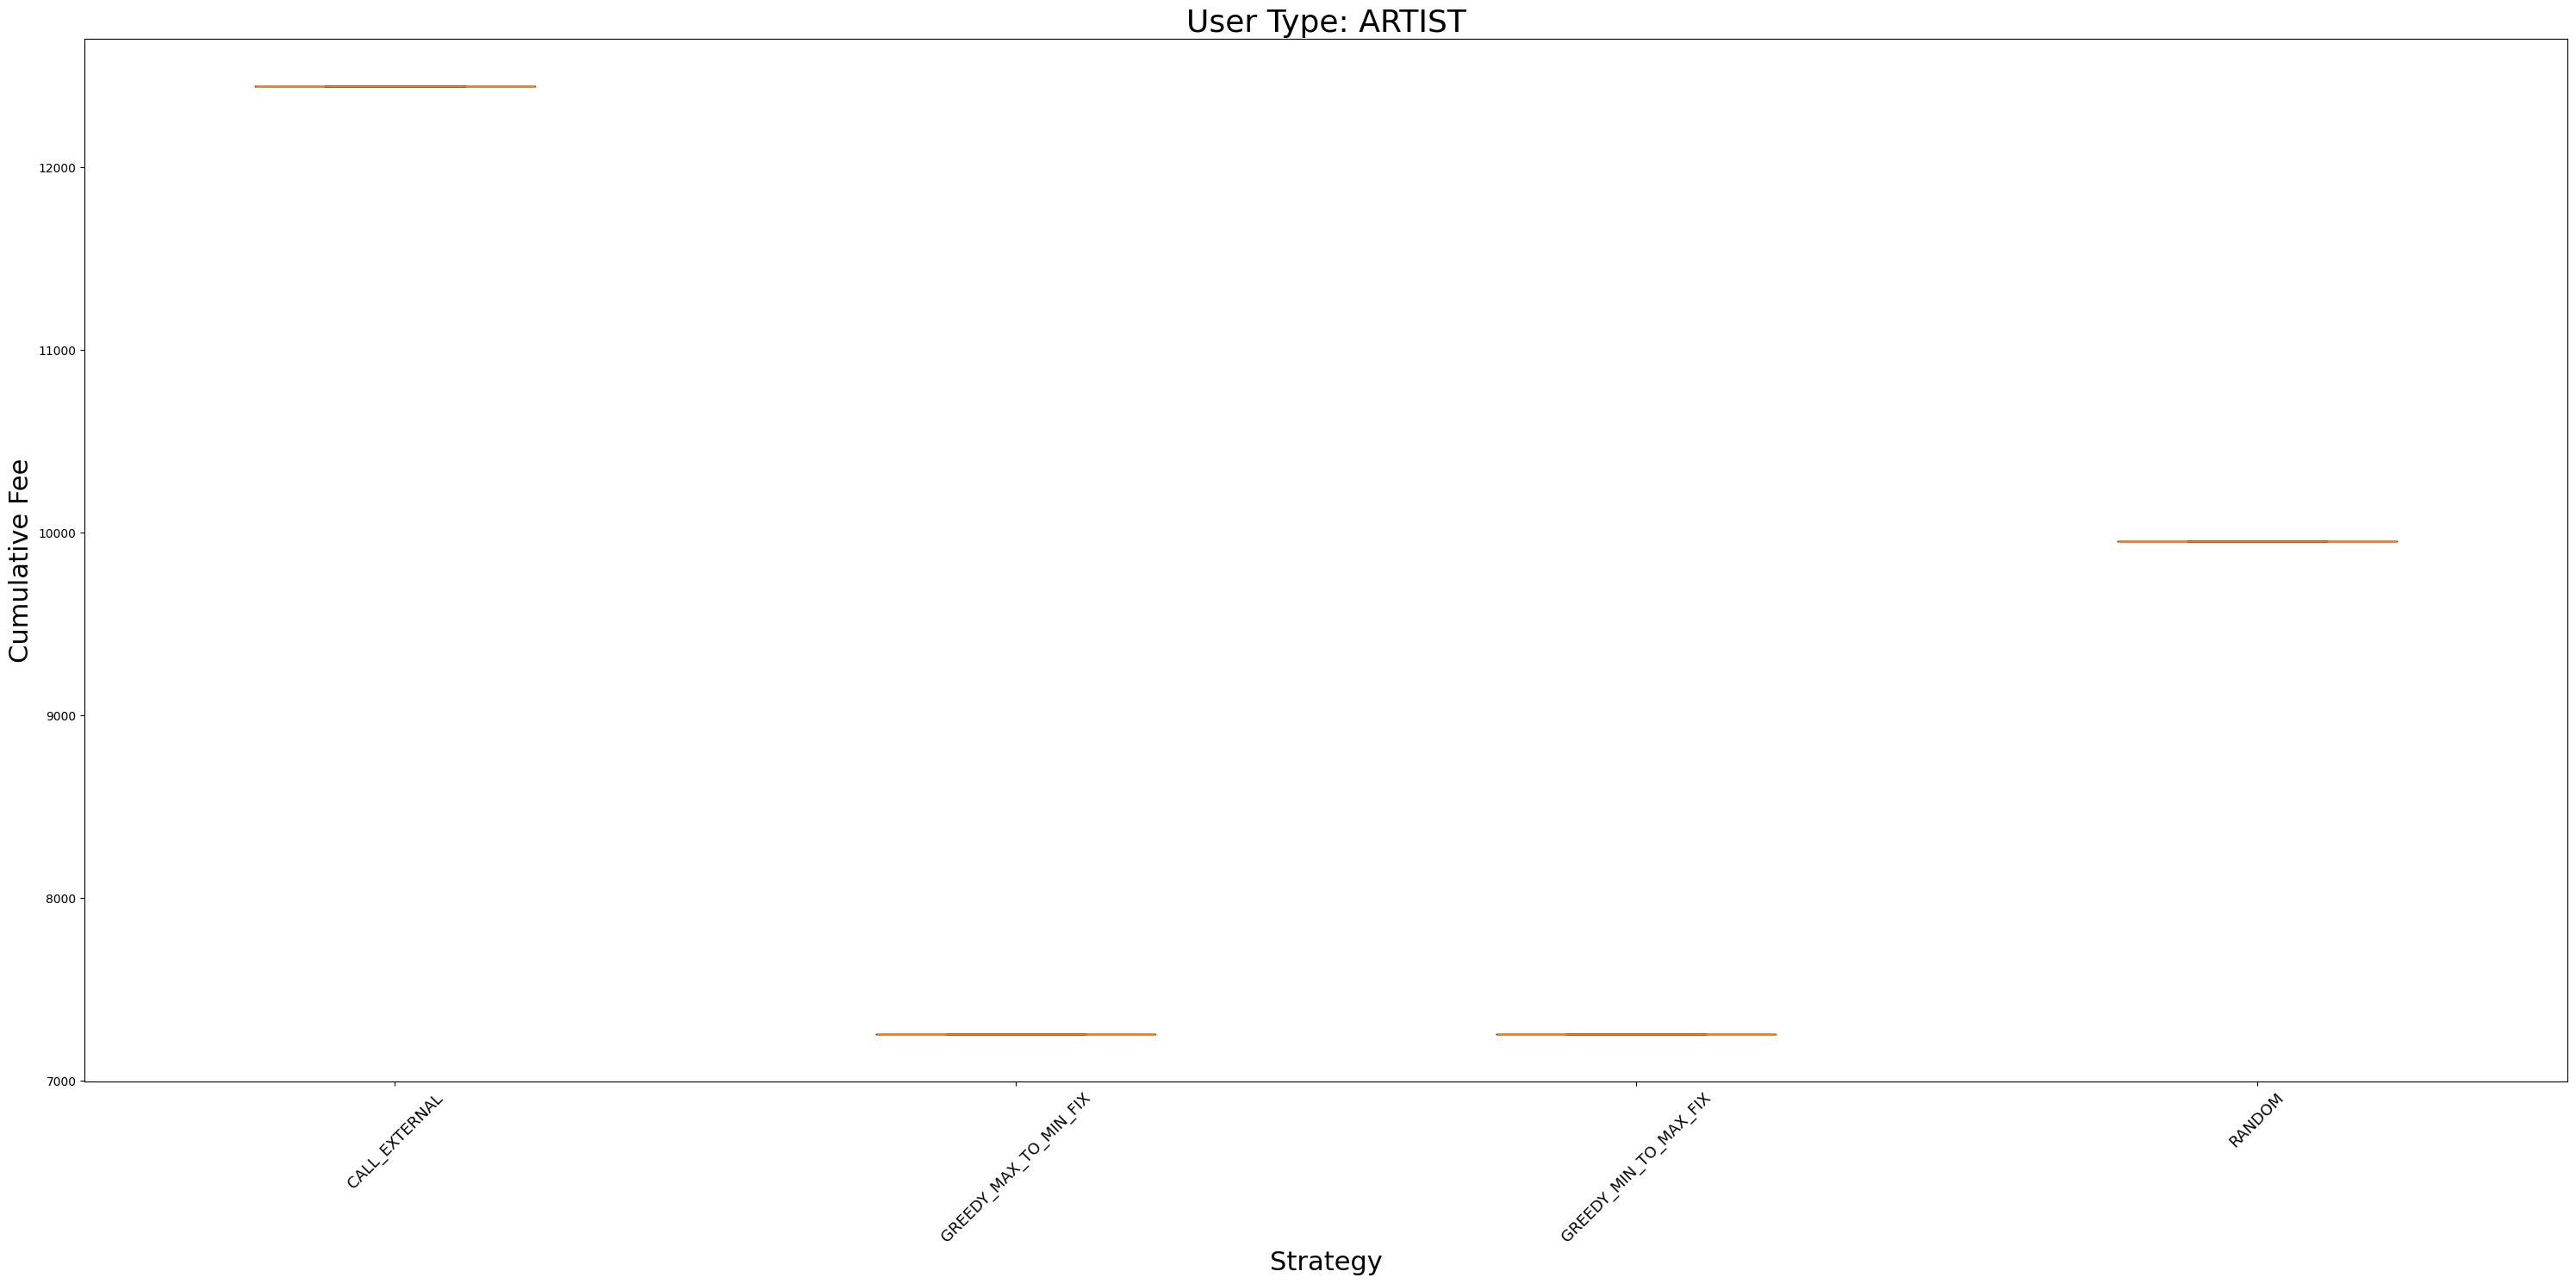

In [15]:
# Calculate cumulative fees for each file within each strategy
df['CumulativeFee'] = df.groupby(['FileName', 'UserType', 'Strategy'])['Fee'].cumsum()

# Create a pivot table for the final cumulative fee for each strategy and user type
final_cumulative_fees = df.drop_duplicates(['FileName', 'UserType', 'Strategy'], keep='last')
# Pivot table adjustment for easier access in the new plot setup
pivot_df_new = final_cumulative_fees.pivot_table(index='UserType', columns='Strategy', values='CumulativeFee', aggfunc=list)

# Plotting setup
num_users = df['UserType'].nunique()
ncols = min(4, num_users)
nrows = np.ceil(num_users / ncols).astype(int)
plot_multiple = ncols * nrows > 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)

axes = axes.ravel()

for idx, (user_type, ax) in enumerate(zip(pivot_df_new.index, axes)):
    # Prepare boxplot data; collect lists from each cell in row corresponding to user type
    boxplot_data = [pivot_df_new.loc[user_type, strategy] for strategy in pivot_df_new.columns]
    ax.boxplot(boxplot_data, tick_labels=pivot_df_new.columns, showfliers=False)  # Optionally add `showfliers=False` to hide outliers
    ax.set_title(f"User Type: {user_type}", fontsize=26)
    ax.set_xlabel('Strategy', fontsize=22)
    ax.set_ylabel('Cumulative Fee', fontsize=22)
    ax.tick_params(axis='x', rotation=45, labelsize=13)

plt.tight_layout()
plt.savefig("results/final_cumulative_fees", bbox_inches='tight')
plt.show()

# Wallet (Deposit) Fee

# Fee Sum over time for each user

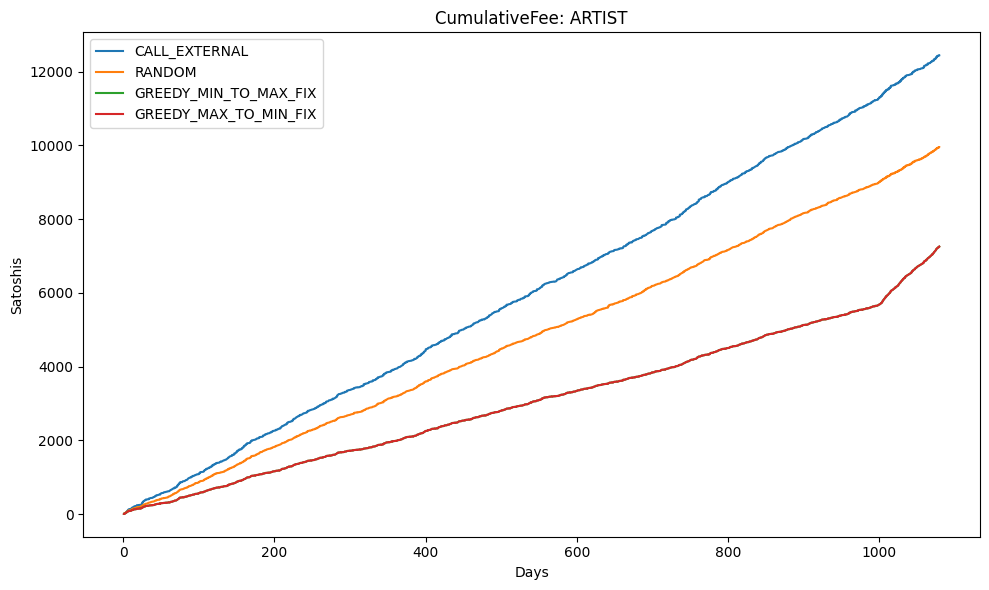

In [16]:
# Plotting setup
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 6))
if (rows * cols > 1):
    axes = axes.ravel()
    
for idx, (user_type, ax) in enumerate(zip(df["UserType"].unique(), axes if cols * rows > 1 else [axes])):
    for strategy in df["Strategy"].unique():       
        df.loc[(df["UserType"] == user_type) & (df["Strategy"] == strategy)].plot("Days", "CumulativeFee", xlabel="Days", ylabel="Satoshis", title="CumulativeFee: " + user_type, label=strategy, ax=ax)

plt.tight_layout()
plt.savefig("results/final_cumulative_fees", bbox_inches='tight', dpi=300)
plt.show()

# Fee Sum including Coins in Wallet

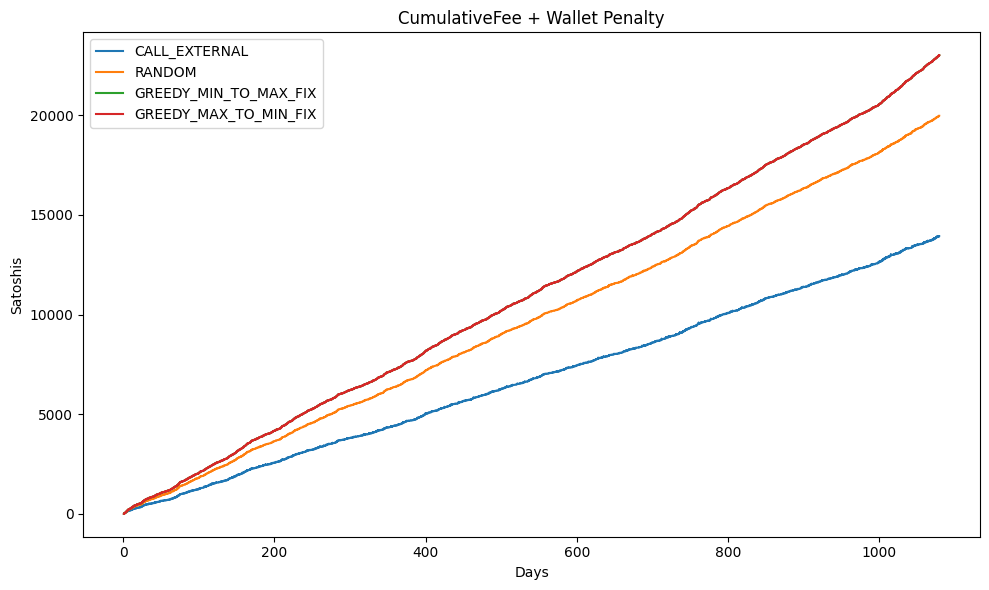

In [17]:
df["FeeSumWallet"] = df["CoinCount"] + df["CumulativeFee"]

# Plotting setup
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 6))
if (rows * cols > 1):
    axes = axes.ravel()
    
for idx, (user_type, ax) in enumerate(zip(df["UserType"].unique(), axes if cols * rows > 1 else [axes])):
    for strategy in df["Strategy"].unique():       
      #  df.loc[(df["UserType"] == user_type) & (df["Strategy"] == strategy)].plot("Days", "CumulativeFee", xlabel="Days", ylabel="Satoshis", title="CumulativeFee: ", label=strategy, ax=ax)
      #  df.loc[(df["UserType"] == user_type) & (df["Strategy"] == strategy)].plot("Days", "CoinCount", xlabel="Days", ylabel="Satoshis", title="CumulativeFee: ", label=strategy, ax=ax)
        df.loc[(df["UserType"] == user_type) & (df["Strategy"] == strategy)].plot("Days", "FeeSumWallet", xlabel="Days", ylabel="Satoshis", title="CumulativeFee + Wallet Penalty", label=strategy, ax=ax)

plt.tight_layout()
plt.savefig("results/final_fees_and_wallet_penalty", bbox_inches='tight', dpi=300)
plt.show()

# Composition of the Fees for each Strategy

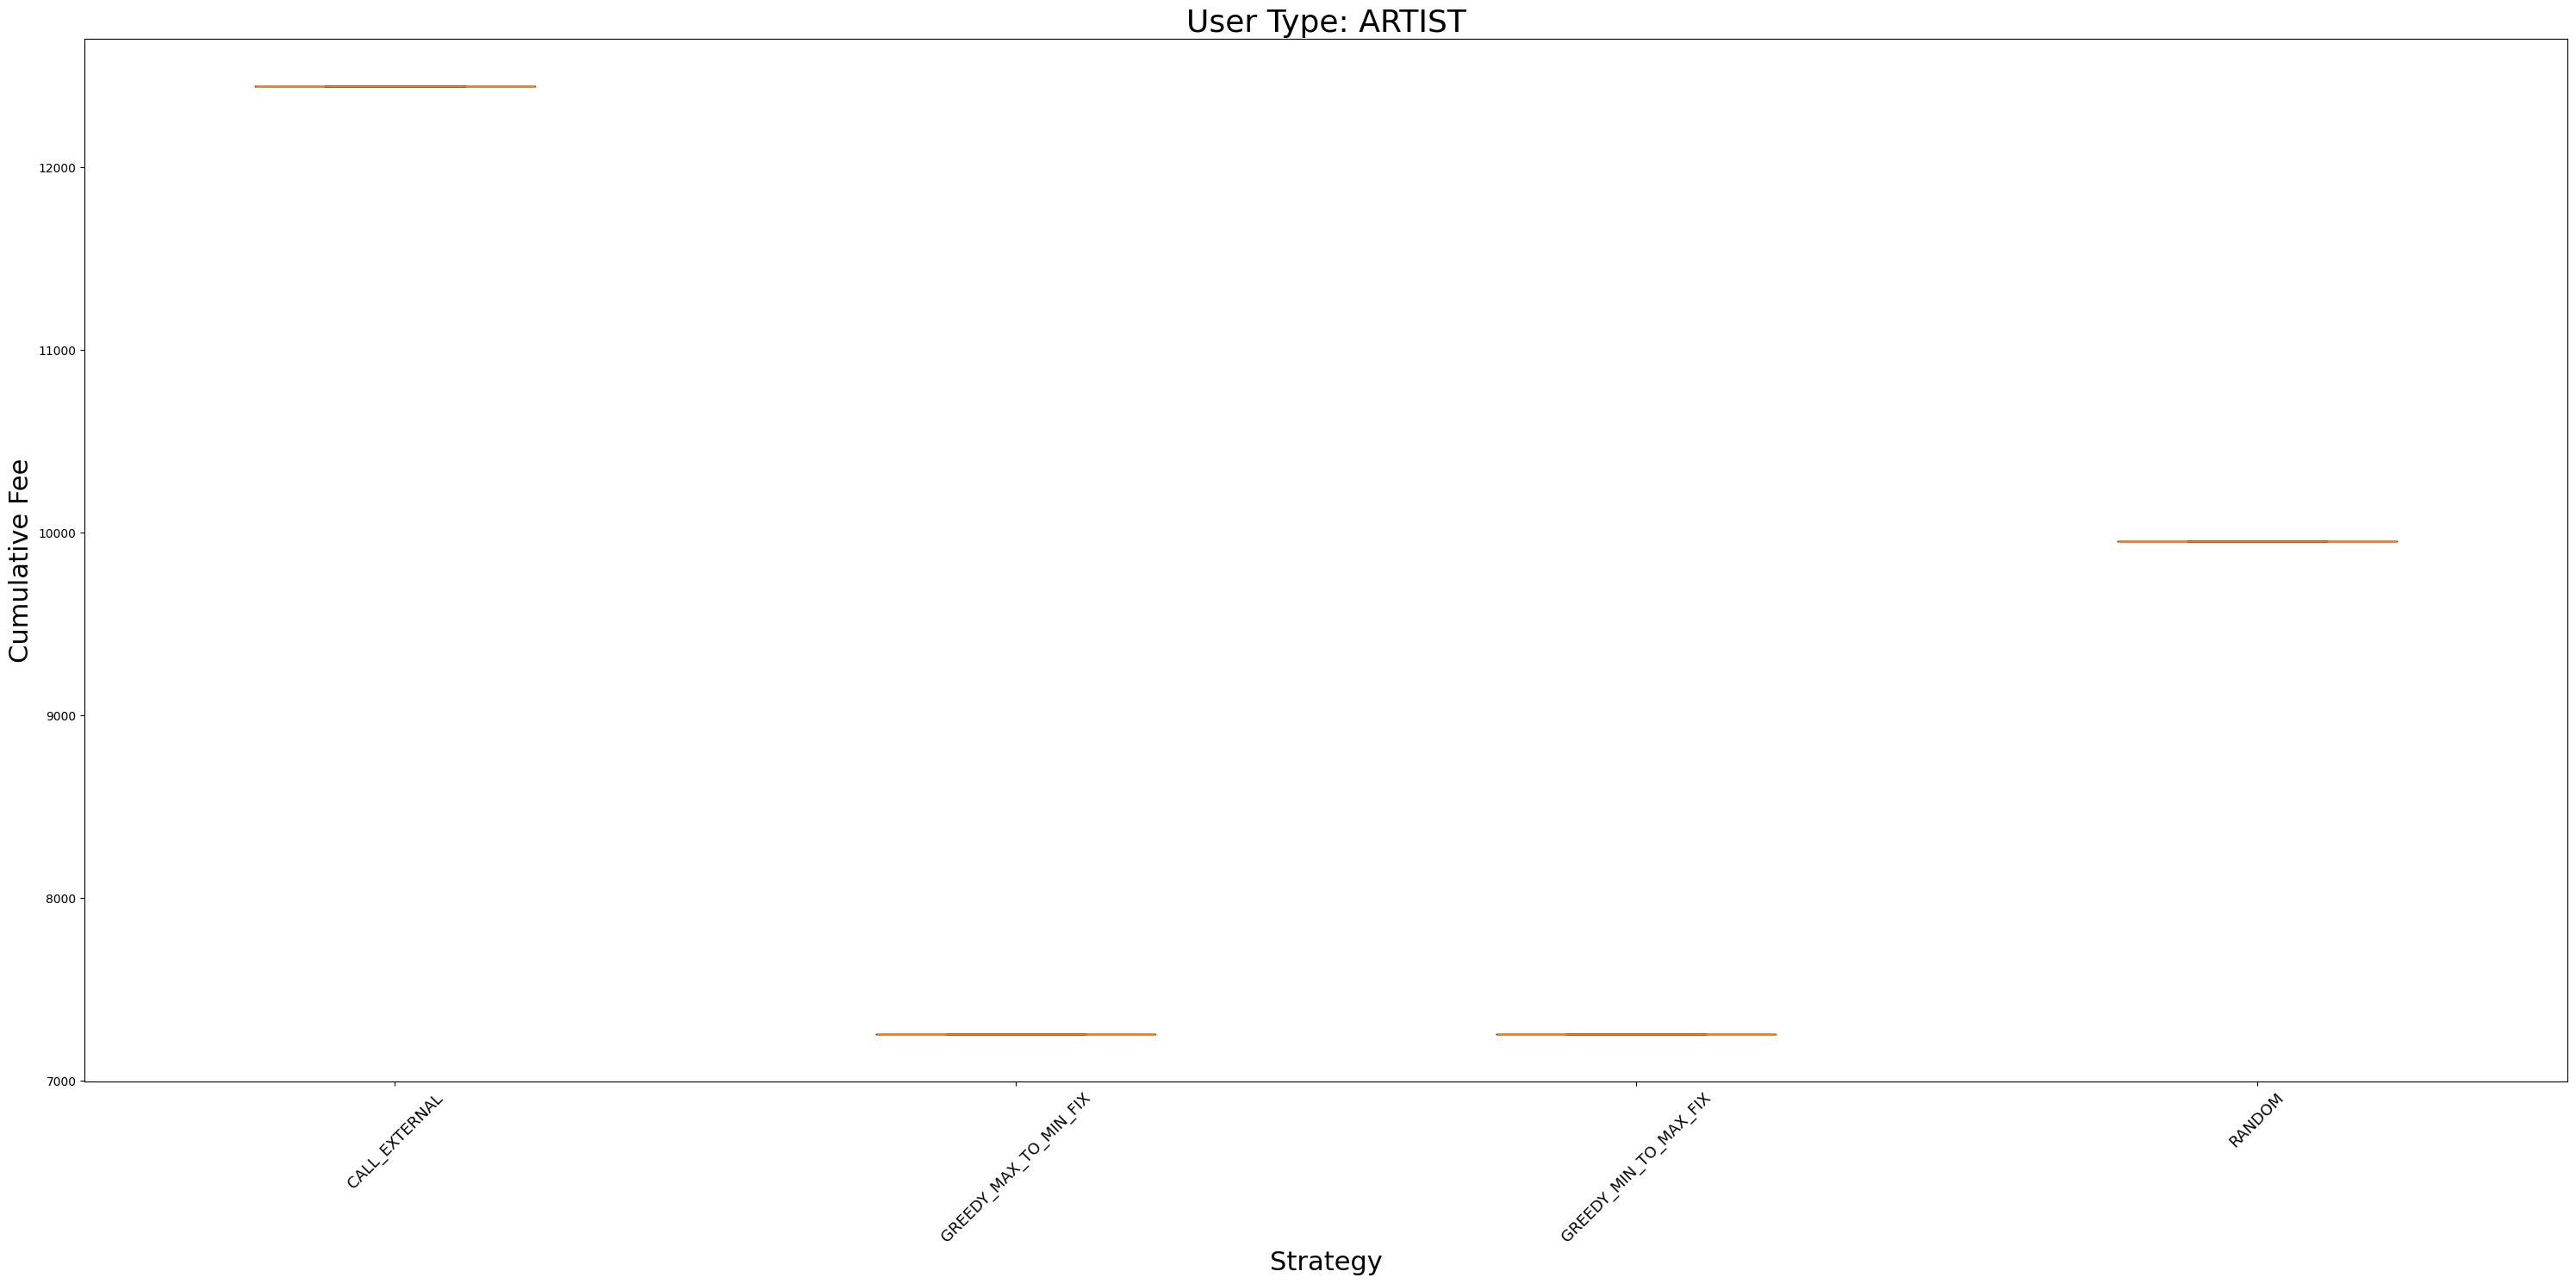

In [18]:
# Calculate cumulative fees for each file within each strategy
df['CumulativeFee'] = df.groupby(['FileName', 'UserType', 'Strategy'])['Fee'].cumsum()

# Create a pivot table for the final cumulative fee for each strategy and user type
final_cumulative_fees = df.drop_duplicates(['FileName', 'UserType', 'Strategy'], keep='last')
# Pivot table adjustment for easier access in the new plot setup
pivot_df_new = final_cumulative_fees.pivot_table(index='UserType', columns='Strategy', values='CumulativeFee', aggfunc=list)

# Plotting setup
num_users = df['UserType'].nunique()
ncols = min(4, num_users)
nrows = np.ceil(num_users / ncols).astype(int)
plot_multiple = ncols * nrows > 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)

axes = axes.ravel()

for idx, (user_type, ax) in enumerate(zip(pivot_df_new.index, axes)):
    # Prepare boxplot data; collect lists from each cell in row corresponding to user type
    boxplot_data = [pivot_df_new.loc[user_type, strategy] for strategy in pivot_df_new.columns]
    ax.boxplot(boxplot_data, tick_labels=pivot_df_new.columns, showfliers=True)  # Optionally add `showfliers=False` to hide outliers
    ax.set_title(f"User Type: {user_type}", fontsize=26)
    ax.set_xlabel('Strategy', fontsize=22)
    ax.set_ylabel('Cumulative Fee', fontsize=22)
    ax.tick_params(axis='x', rotation=45, labelsize=13)

plt.tight_layout()
plt.savefig("results/final_cumulative_fees", bbox_inches='tight', dpi=300)
plt.show()

# Summe der genutzten Bandbreite pro User

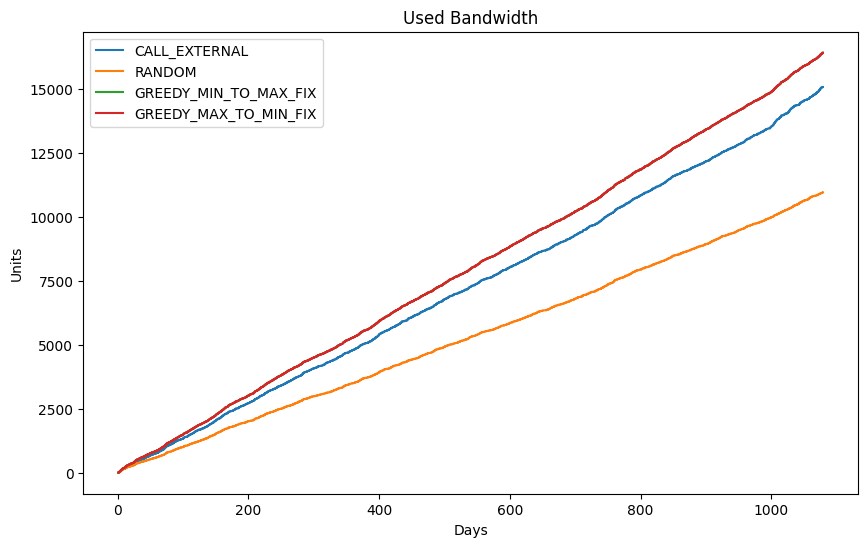

In [19]:

#print(file_groups["CoinCount"].shift(1, fill_value=0) - file_groups["CoinCount"])
df["UsedDiskSpace"] = df["CoinCount"]
df["UsedBandwidth"] = 0
df["UsedBandwidth"] = df.groupby(['FileName', 'UserType', 'Strategy'])["CoinCount"].diff().abs().fillna(0).groupby(df['Strategy']).cumsum()

# Plotting setup
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 6))
if (rows * cols > 1):
    axes = axes.ravel()
    
for idx, (user_type, ax) in enumerate(zip(df["UserType"].unique(), axes if cols * rows > 1 else [axes])):
    for strategy in df["Strategy"].unique():       
        df.loc[(df["UserType"] == user_type) & (df["Strategy"] == strategy)].plot("Days", "UsedBandwidth", xlabel="Days", ylabel="Units", title="Used Bandwidth", label=strategy, ax=ax)
plt.savefig("results/final_bandwidth", bbox_inches='tight', dpi=300)
plt.show()


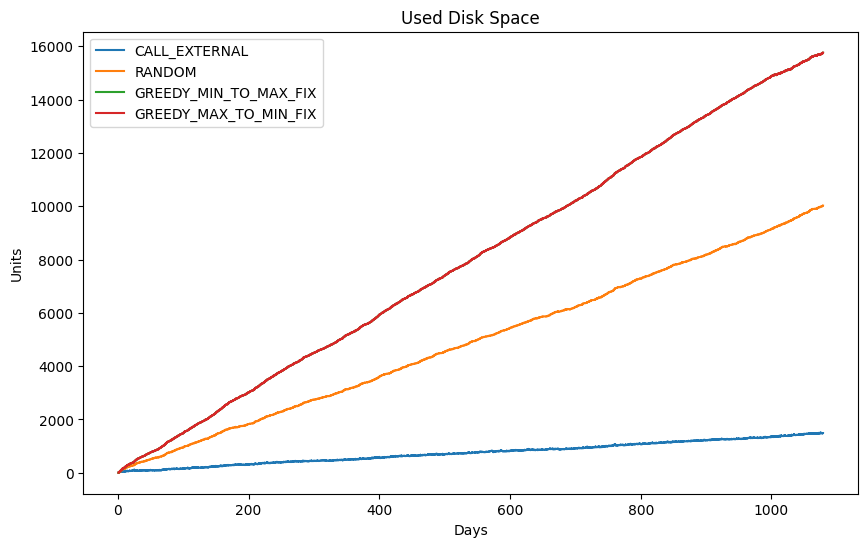

In [20]:
# Plotting setup
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 6))
if (rows * cols > 1):
    axes = axes.ravel()
    
for idx, (user_type, ax) in enumerate(zip(df["UserType"].unique(), axes if cols * rows > 1 else [axes])):
    for strategy in df["Strategy"].unique():       
        df.loc[(df["UserType"] == user_type) & (df["Strategy"] == strategy)].plot("Days", "UsedDiskSpace", xlabel="Days", ylabel="Units", title="Used Disk Space", label=strategy, ax=ax)
plt.savefig("results/final_diskspace", bbox_inches='tight', dpi=300)
plt.show()


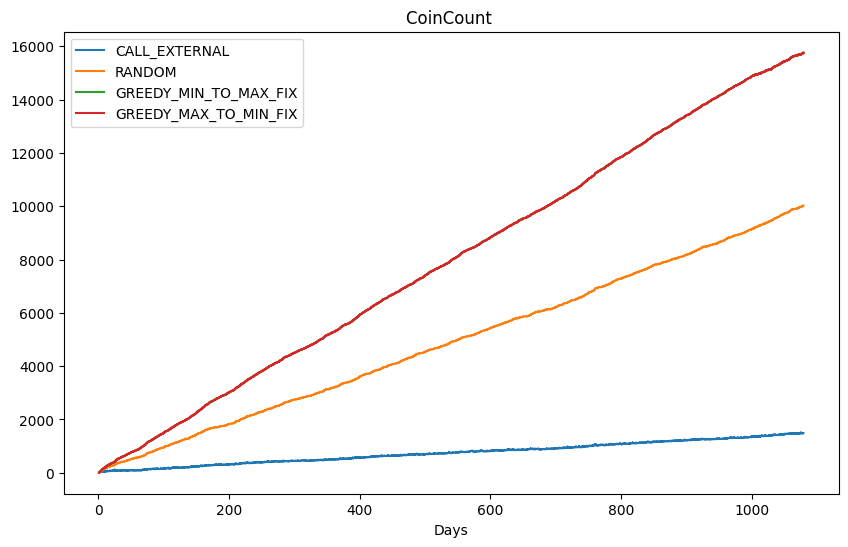

In [21]:
# Plotting setup
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 6))
if (rows * cols > 1):
    axes = axes.ravel()
    
for idx, (user_type, ax) in enumerate(zip(df["UserType"].unique(), axes if cols * rows > 1 else [axes])):
    for strategy in df["Strategy"].unique():       
        df.loc[(df["UserType"] == user_type) & (df["Strategy"] == strategy)].plot("Days", "CoinCount", xlabel="Days", title="CoinCount ", label=strategy, ax=ax)

plt.show()



['CALL_EXTERNAL' 'RANDOM' 'GREEDY_MIN_TO_MAX_FIX' 'GREEDY_MAX_TO_MIN_FIX']


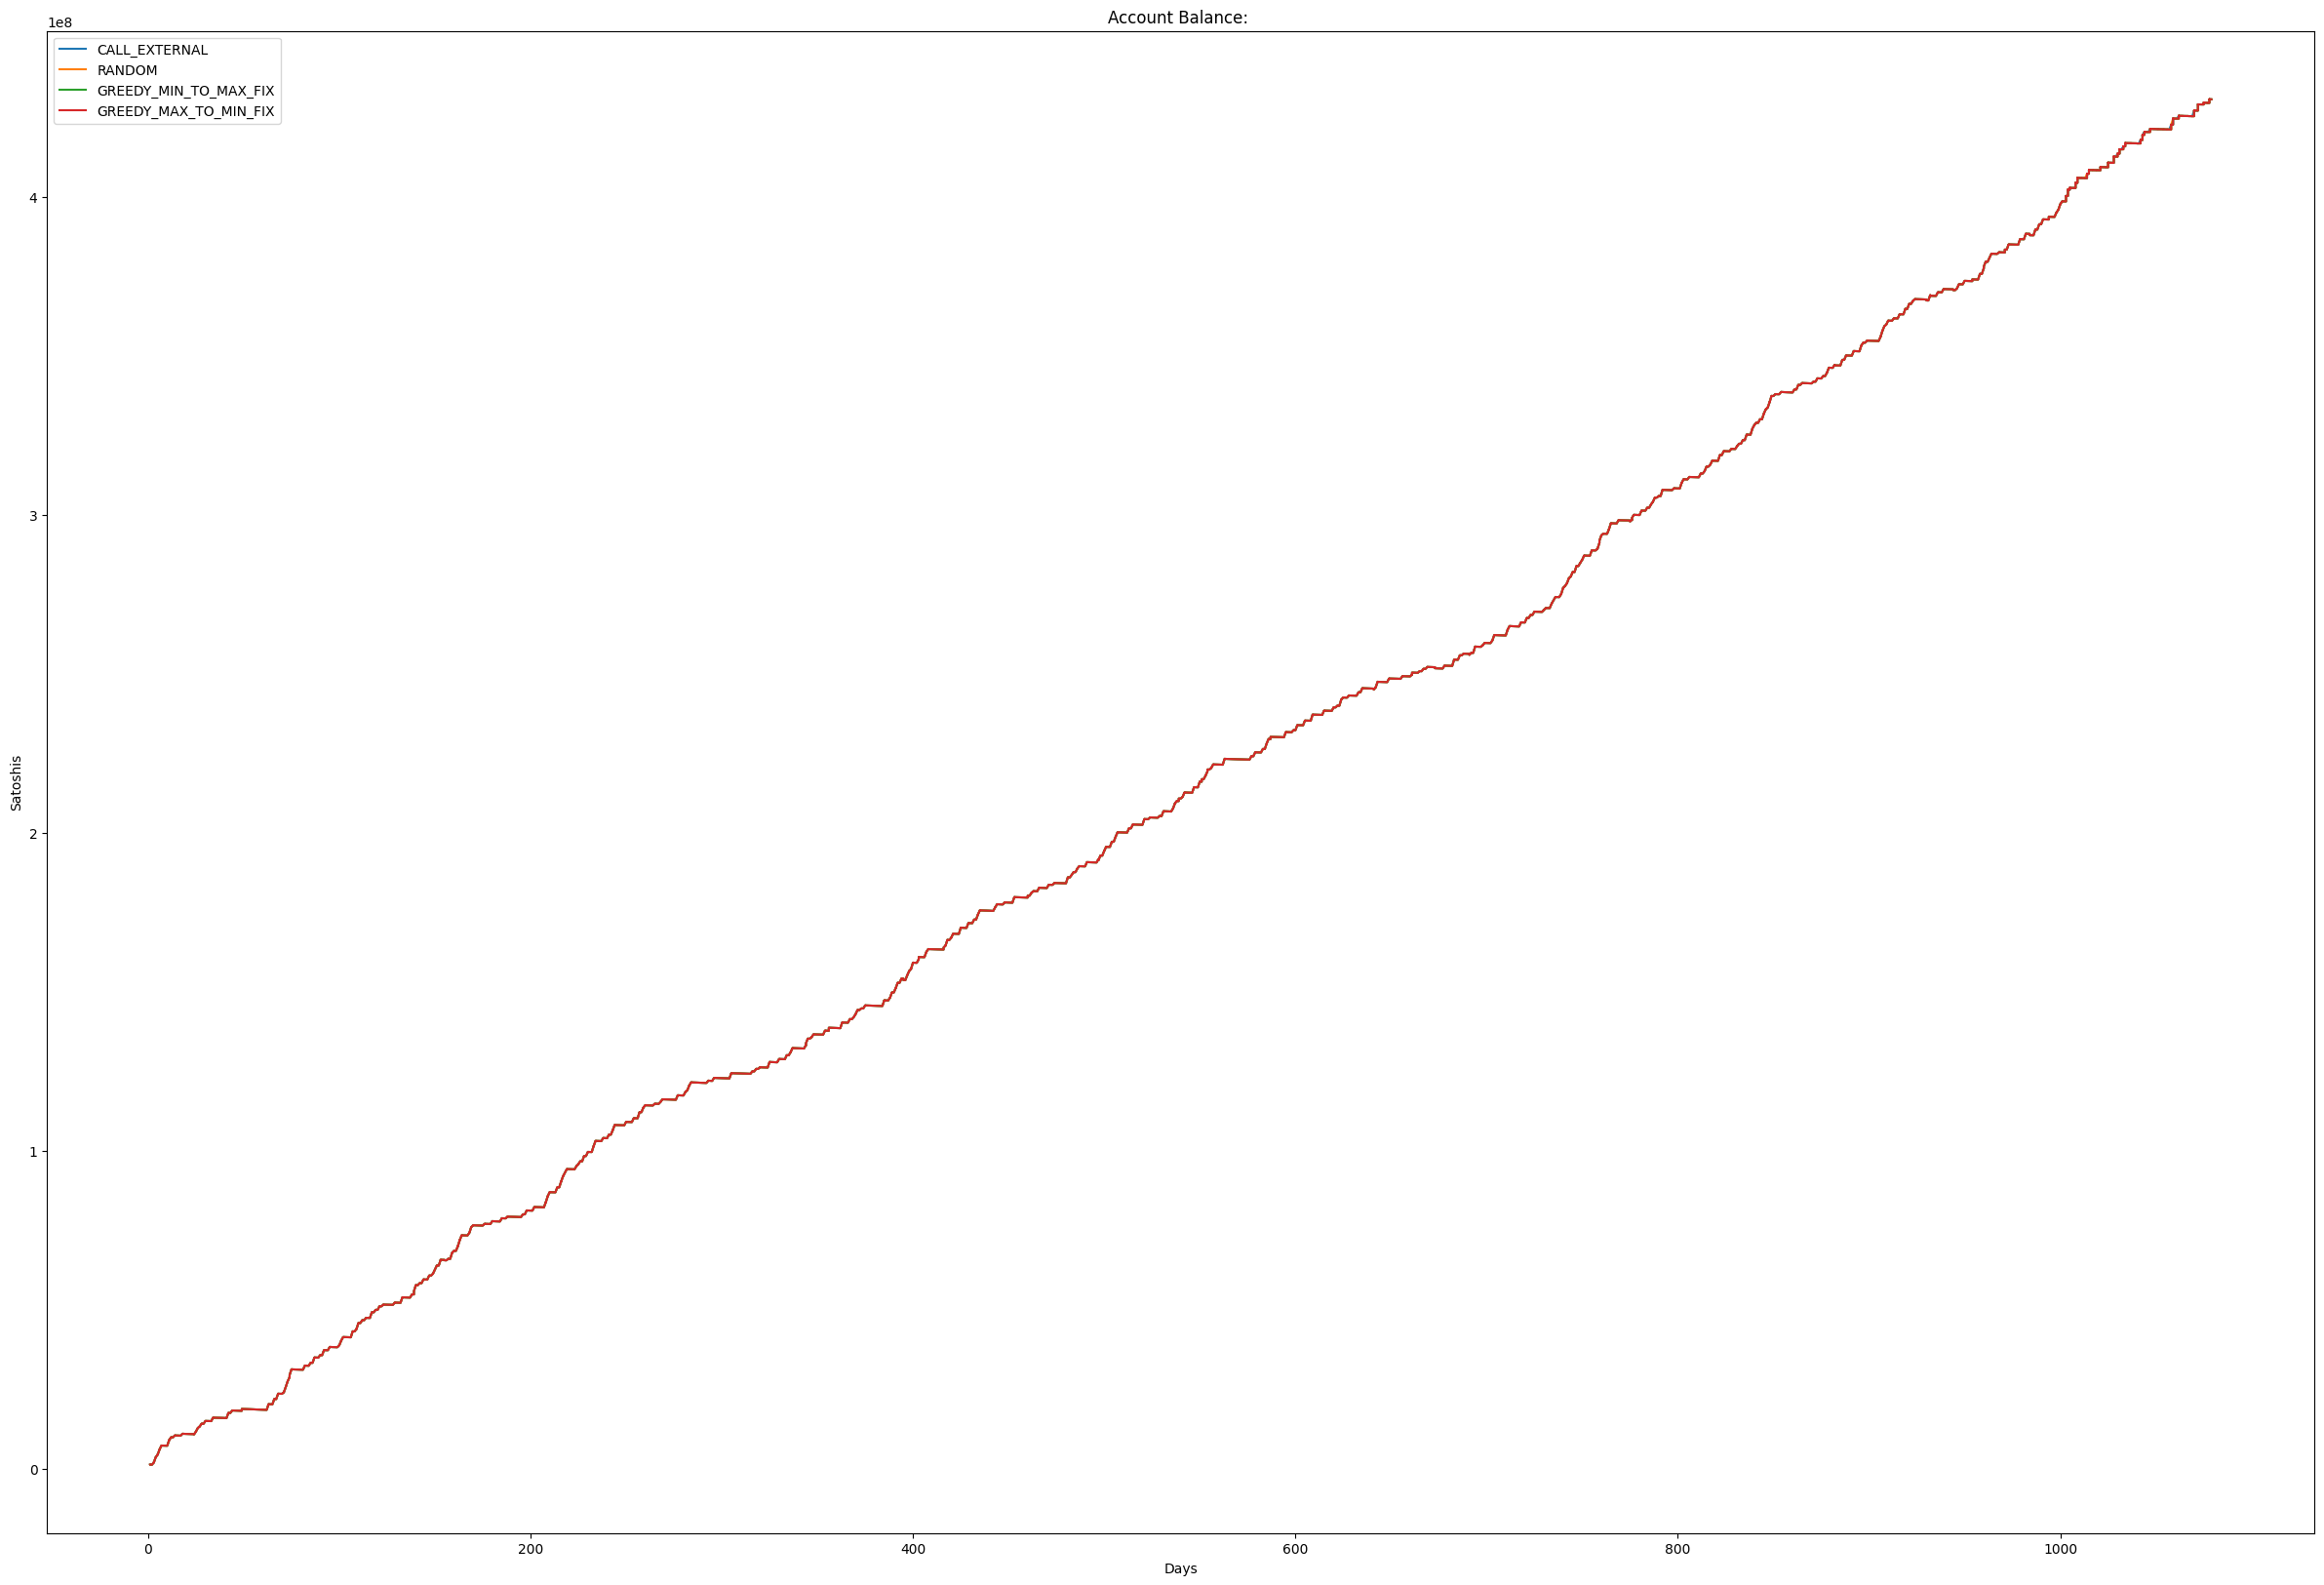

In [22]:
t_min, t_max = 0, 1300
selected_strategy = "RANDOM"

print(df["Strategy"].unique())

time_limit = (df.index)

# Plotting setup
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(30, 20))
if (rows * cols > 1):
    axes = axes.ravel()

for idx, (user_type, ax) in enumerate(zip(df["UserType"].unique(), axes if cols * rows > 1 else [axes])):
    for strategy in df["Strategy"].unique():       
        df.loc[(df["UserType"] == user_type) & (df["Strategy"] == strategy)& (df["Days"] > t_min) & (df["Days"] < t_max)].plot("Days", "Balance", xlabel="Days", ylabel="Satoshis", title="Account Balance: ", label=strategy, ax=ax)
plt.savefig("results/final_balance", bbox_inches='tight', dpi=300)
plt.show()

#print(df.loc[(df["Strategy"] == selected_strategy) & (df["Days"] > t_min) & (df["Days"] < t_max)]["SignAmount"].sum())
#print(df.loc[(df["Strategy"] == "CALL_EXTERNAL") & (df["Days"] > t_min) & (df["Days"] < t_max)]["SignAmount"].sum())
#print(df.loc[(df["Strategy"] == selected_strategy) & (df["Days"] > t_min) & (df["Days"] < t_max)][["Days", "Amount", "SignAmount", "Balance", "Operation"]][:100].to_string())
#print(df.loc[(df["Strategy"] == "CALL_EXTERNAL") & (df["Days"] > t_min) & (df["Days"] < t_max)][["Days", "Amount", "SignAmount", "Balance", "Operation"]][:100].to_string())
    
